# Classification par K-Plus Proches Voisins (KNN)

**Objectif :** Prédire le sexe d'un individu (Femme / Homme) à partir de sa taille et de son poids, en implémentant l'algorithme KNN avec NumPy.


## 1. Imports & Génération des données

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import cdist
np.random.seed(42)

In [2]:
def make_blobs(n_samples, centers, cluster_std):
    centers = np.array(centers)
    n_centers = centers.shape[0]
    n_features = centers.shape[1]

    X, y = [], []
    n_per_center = [n_samples // n_centers] * n_centers
    for i in range(n_samples % n_centers):
        n_per_center[i] += 1

    for i, (n, std) in enumerate(zip(n_per_center, cluster_std)):
        X.append(np.random.normal(loc=centers[i], scale=std, size=(n, n_features)))
        y += [i] * n

    return np.concatenate(X), np.array(y)


def load_data(n_individuals, seed=None):
    if seed is not None:
        np.random.seed(seed)
    X, y = make_blobs(
        n_samples=n_individuals,
        centers=[[164, 64], [177, 79]],   # Femme, Homme
        cluster_std=[[10, 5], [10, 5]]
    )
    y_str = np.empty(y.shape, dtype=str)
    y_str[y == 0] = "F"
    y_str[y == 1] = "H"
    return X, y_str


# Chargement des données
X_train, y_train = load_data(200, seed=42)
X_test, y_test   = load_data(40,  seed=99)

print(f"Taille du jeu d'entraînement : {X_train.shape[0]} individus")
print(f"Taille du jeu de test        : {X_test.shape[0]} individus")

Taille du jeu d'entraînement : 200 individus
Taille du jeu de test        : 40 individus


## 2. Exploration du Dataset

In [3]:
# --- Statistiques descriptives ---
import pandas as pd

df_train = pd.DataFrame(X_train, columns=["Taille (cm)", "Poids (kg)"])
df_train["Sexe"] = y_train

print("Aperçu du dataset")
print(df_train.head(8).to_string(index=False))
print()
print("Statistiques globales")
print(df_train[["Taille (cm)", "Poids (kg)"]].describe().round(2))

Aperçu du dataset
 Taille (cm)  Poids (kg) Sexe
  168.967142   63.308678    F
  170.476885   71.615149    F
  161.658466   62.829315    F
  179.792128   67.837174    F
  159.305256   66.712800    F
  159.365823   61.671351    F
  166.419623   54.433599    F
  146.750822   61.188562    F

Statistiques globales
       Taille (cm)  Poids (kg)
count       200.00      200.00
mean        170.56       71.69
std          12.25        8.95
min         137.80       54.06
25%         162.31       64.72
50%         169.25       71.91
75%         179.29       79.05
max         200.15       98.26


In [4]:
# --- Distribution des classes ---
counts = {"F": np.sum(y_train == "F"), "H": np.sum(y_train == "H")}
print("Distribution des classes (train)")
for label, count in counts.items():
    pct = count / len(y_train) * 100
    print(f"  {label} : {count} individus ({pct:.1f}%)")

Distribution des classes (train)
  F : 100 individus (50.0%)
  H : 100 individus (50.0%)


In [5]:
# --- Statistiques par classe ---
print("Statistiques par classe")
for label in ["F", "H"]:
    mask = y_train == label
    taille = X_train[mask, 0]
    poids  = X_train[mask, 1]
    print(f"\n  [{label}]")
    print(f"    Taille : moyenne = {taille.mean():.1f} cm, std = {taille.std():.1f} cm, min = {taille.min():.1f}, max = {taille.max():.1f}")
    print(f"    Poids  : moyenne = {poids.mean():.1f} kg,  std = {poids.std():.1f} kg,  min = {poids.min():.1f}, max = {poids.max():.1f}")

Statistiques par classe

  [F]
    Taille : moyenne = 162.8 cm, std = 8.5 cm, min = 137.8, max = 182.9
    Poids  : moyenne = 64.2 kg,  std = 5.0 kg,  min = 54.1, max = 77.6

  [H]
    Taille : moyenne = 178.3 cm, std = 10.3 cm, min = 144.6, max = 200.1
    Poids  : moyenne = 79.2 kg,  std = 4.7 kg,  min = 69.2, max = 98.3


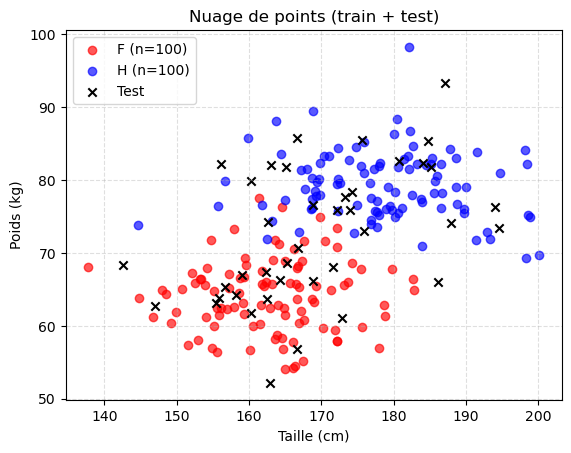

In [6]:
# --- Visualisation du dataset ---

# Scatter plot principal
for label, color in [("F", "red"), ("H", "blue")]:
    mask = y_train == label
    plt.scatter(X_train[mask, 0], X_train[mask, 1],
                color=color, alpha=0.65, label=f"{label} (n={mask.sum()})")

plt.scatter(X_test[:, 0], X_test[:, 1], marker="x", color="black", label="Test")
plt.xlabel("Taille (cm)")
plt.ylabel("Poids (kg)")
plt.title("Nuage de points (train + test)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## 3. Implémentation du KNN (NumPy)

L'algorithme KNN repose sur une idée simple : **un individu inconnu est classé selon la majorité des classes de ses k voisins les plus proches** dans l'espace des features.

**Distance utilisée :** distance euclidienne  
$$d(X_i, X_j) = \sqrt{\sum_{l=1}^{d}(X_i^l - X_j^l)^2}$$

On utilise `cdist` de SciPy pour calculer toutes les distances en une seule opération vectorisée — beaucoup plus efficace que des boucles Python.

In [7]:
def knn_predict(X_train, y_train, X_test, k=1):
    # Étape 1 : matrice des distances (n_test × n_train)
    distances = cdist(X_test, X_train, metric="euclidean")

    # Étape 2 : indices des k plus proches voisins pour chaque individu de test
    knn_indices = np.argsort(distances, axis=1)[:, :k]

    # Étape 3 : récupérer les labels de ces voisins
    knn_labels = y_train[knn_indices]   # shape (n_test, k)

    # Étape 4 : vote majoritaire — on compte les "F" et on en déduit le label
    count_F = np.sum(knn_labels == "F", axis=1)
    y_pred = np.where(count_F > k / 2, "F", "H")

    return y_pred


# Test rapide
y_pred = knn_predict(X_train, y_train, X_test, k=5)
print("Prédictions (k=5) :")
print("  Vraies classes :", y_test[:10])
print("  Prédictions    :", y_pred[:10])

Prédictions (k=5) :
  Vraies classes : ['F' 'F' 'F' 'F' 'F' 'F' 'F' 'F' 'F' 'F']
  Prédictions    : ['H' 'F' 'F' 'F' 'F' 'F' 'F' 'F' 'F' 'F']


## 4. Évaluation du modèle & Métriques

Pour évaluer la qualité d'un classifieur, l'accuracy seule peut être trompeuse. On calcule également la **matrice de confusion** ainsi que les métriques **précision**, **rappel** et **F1-score**.

In [8]:
def compute_metrics(y_true, y_pred, positive_class="F"):
    accuracy = np.mean(y_true == y_pred)

    # Matrice de confusion
    classes = ["F", "H"]
    cm = np.zeros((2, 2), dtype=int)
    for i, true in enumerate(classes):
        for j, pred in enumerate(classes):
            cm[i, j] = np.sum((y_true == true) & (y_pred == pred))

    # Métriques pour la classe positive
    idx = classes.index(positive_class)
    TP = cm[idx, idx]
    FP = cm[:, idx].sum() - TP
    FN = cm[idx, :].sum() - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "accuracy"  : accuracy,
        "precision" : precision,
        "recall"    : recall,
        "f1"        : f1,
        "cm"        : cm
    }


def print_metrics(metrics, k):
    print(f"Résultats pour k = {k}")
    print(f"  Accuracy  : {metrics['accuracy']:.3f}")
    print(f"  Précision : {metrics['precision']:.3f}")
    print(f"  Rappel    : {metrics['recall']:.3f}")
    print(f"  F1-score  : {metrics['f1']:.3f}")



k = 5
y_pred = knn_predict(X_train, y_train, X_test, k=k)
metrics = compute_metrics(y_test, y_pred)
print_metrics(metrics, k)

Résultats pour k = 5
  Accuracy  : 0.975
  Précision : 1.000
  Rappel    : 0.950
  F1-score  : 0.974


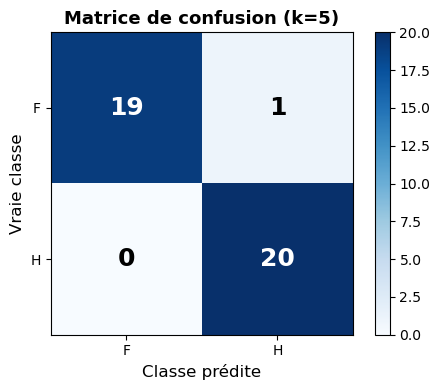

In [9]:
fig = plt.figure(figsize=(5, 4))
cm = metrics["cm"]
classes = ["F", "H"]

plt.imshow(cm, cmap="Blues", vmin=0)
plt.colorbar()

plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)
plt.xlabel("Classe prédite", fontsize=12)
plt.ylabel("Vraie classe", fontsize=12)
plt.title(f"Matrice de confusion (k={k})", fontsize=13, fontweight="bold")

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                 fontsize=18, fontweight="bold", color=color)

plt.tight_layout()
plt.show()

**Matrice de confusion (k=5)**  
Le modèle classifie correctement 39 individus sur 40, soit une accuracy de 97,5%. La seule erreur est une femme prédite comme homme, ce qui est probablement dû à un individu atypique dont les mesures se rapprochent davantage de celles des hommes.

Ces résultats sont attendus car le dataset est synthétique et relativement simple - les deux classes sont bien séparées dans l'espace taille/poids.

## 5. Influence du paramètre k

Le choix de **k** est crucial :
- Un k trop petit (**k=1**) → le modèle colle au bruit des données → **surapprentissage** (overfitting)
- Un k trop grand → le modèle lisse trop les frontières → **sous-apprentissage** (underfitting)

On évalue l'accuracy pour différentes valeurs de k afin de trouver le **meilleur compromis**.

In [10]:
k_values = list(range(1, 31, 2))  # valeurs impaires pour éviter les égalités
accuracies_test  = []
accuracies_train = []

for k in k_values:
    # Performance sur le jeu de test
    y_pred_test = knn_predict(X_train, y_train, X_test, k=k)
    accuracies_test.append(np.mean(y_pred_test == y_test))

    # Performance sur le jeu d'entraînement (pour détecter l'overfitting)
    y_pred_train = knn_predict(X_train, y_train, X_train, k=k)
    accuracies_train.append(np.mean(y_pred_train == y_train))

best_k = k_values[np.argmax(accuracies_test)]
best_acc = max(accuracies_test)

print(f"Meilleur k sur le jeu de test : k = {best_k} (accuracy = {best_acc:.3f})")

Meilleur k sur le jeu de test : k = 7 (accuracy = 1.000)


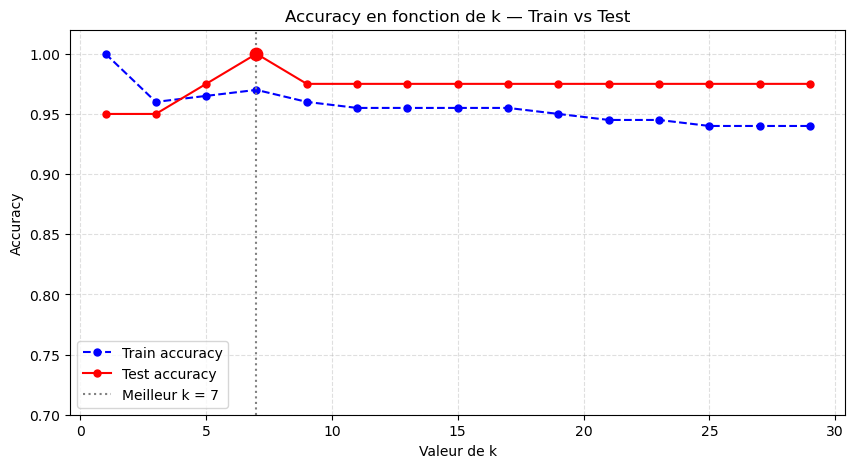

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(k_values, accuracies_train, "o--", color="blue", linewidth=1.5, markersize=5, label="Train accuracy")
plt.plot(k_values, accuracies_test, "o-", color="red", linewidth=1.5, markersize=5, label="Test accuracy")
plt.axvline(best_k, color="gray", linestyle=":", linewidth=1.5, label=f"Meilleur k = {best_k}")
plt.scatter([best_k], [best_acc], color="red", zorder=5, s=80)

plt.xlabel("Valeur de k")
plt.ylabel("Accuracy")
plt.title("Accuracy en fonction de k — Train vs Test")
plt.legend()
plt.ylim(0.7, 1.02)
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

**Choix de K**
-  Pour k=1 : accuracy train = 1.0 (le modèle mémorise parfaitement) → overfitting.
- Au-delà d'un certain k, la performance test se stabilise ou diminue → underfitting.
-  Le meilleur compromis ici est k = 7, car l'accuracy sur le jeu de test est maximale.

## 6. Visualisation des Frontières de Décision

Une **frontière de décision** est la limite dans l'espace des features où le modèle change de prédiction. Pour KNN, cette frontière n'est pas linéaire — elle s'adapte aux données.

On compare ci-dessous des frontières pour différentes valeurs de k.

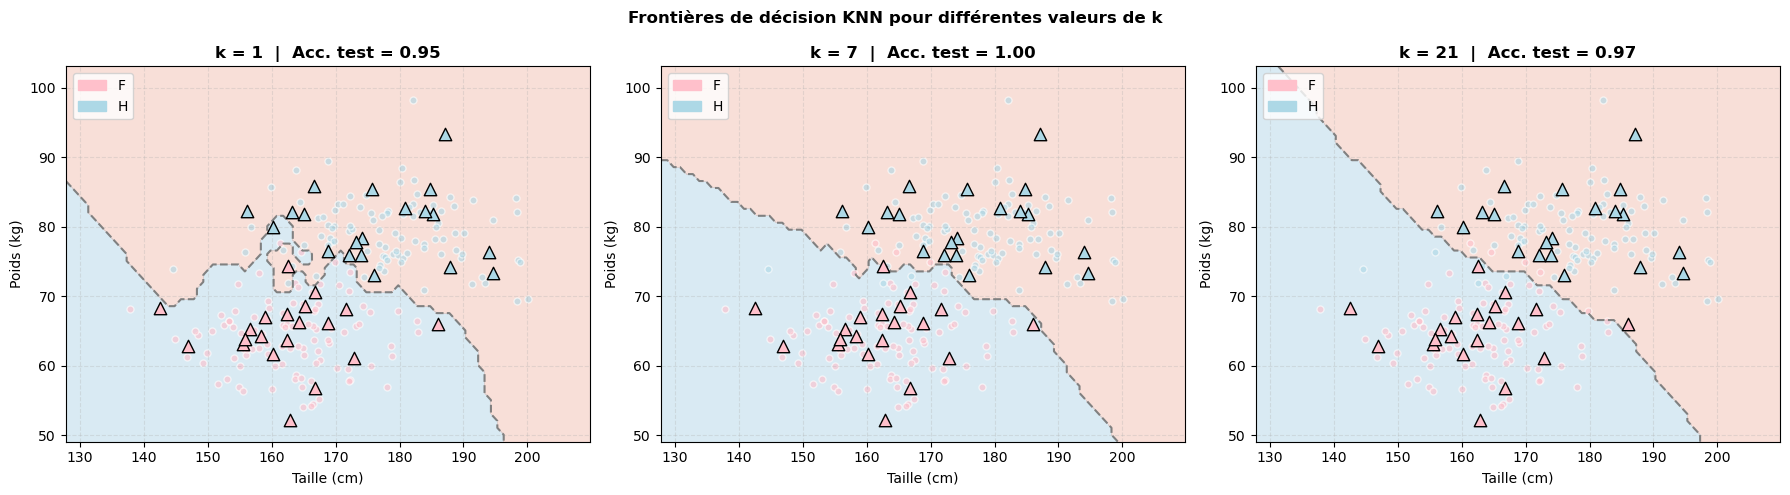

In [14]:
h = 1.0
x_min, x_max = X_train[:, 0].min() - 10, X_train[:, 0].max() + 10
y_min, y_max = X_train[:, 1].min() - 5,  X_train[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

k_list = [1, best_k, 21]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Frontières de décision KNN pour différentes valeurs de k", fontweight="bold")

for ax, k in zip(axes, k_list):
    Z = np.where(knn_predict(X_train, y_train, grid, k=k) == "F", 0, 1).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdBu_r, levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, Z, levels=[0.5], colors="gray", linewidths=1.5, linestyles="--")

    for label, color in [("F", "pink"), ("H", "lightblue")]:
        ax.scatter(X_train[y_train == label, 0], X_train[y_train == label, 1],
                   color=color, alpha=0.6, s=25, edgecolors="white")
        ax.scatter(X_test[y_test == label, 0], X_test[y_test == label, 1],
                   marker="^", color=color, s=80, edgecolors="black", zorder=5)

    acc = np.mean(knn_predict(X_train, y_train, X_test, k=k) == y_test)
    ax.set_title(f"k = {k}  |  Acc. test = {acc:.2f}", fontweight="bold")
    ax.set_xlabel("Taille (cm)")
    ax.set_ylabel("Poids (kg)")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(handles=[mpatches.Patch(color="pink", label="F"),
                       mpatches.Patch(color="lightblue", label="H")], loc="upper left")

plt.tight_layout()
plt.show()

**Observations :**  
- k=1 : frontière très irrégulière, le modèle réagit au moindre point → risque d'overfitting.
- k=7 : frontière plus lisse, meilleur équilibre biais/variance.
- k=21 : frontière trop lisse, certaines zones mal classées → underfitting.

## 7. Rapport final des performances

Récapitulatif des métriques pour le k=7.

In [13]:
y_pred_best = knn_predict(X_train, y_train, X_test, k=best_k)
metrics_best = compute_metrics(y_test, y_pred_best)

print(f"Accuracy   : {metrics_best['accuracy']:.3f}")
print(f"Précision  : {metrics_best['precision']:.3f}")
print(f"Rappel     : {metrics_best['recall']:.3f}")
print(f"F1-score   : {metrics_best['f1']:.3f}")

Accuracy   : 1.000
Précision  : 1.000
Rappel     : 1.000
F1-score   : 1.000


**Résultats**  
Toutes les métriques sont à 1.0, ce qui signifie que le modèle a classifié **parfaitement** tous les individus du jeu de test.

## 8. Conclusion

Ce dataset synthétique est un cas idéal pour le KNN : il contient peu d'individus, seulement 2 features (taille et poids), et les deux classes sont globalement bien séparées dans l'espace. Dans ce contexte, l'algorithme n'a aucune difficulté à identifier des voisins pertinents, ce qui explique les très bonnes performances obtenues.

### Ce qu'on a fait
- Généré et exploré un dataset synthétique de **taille/poids** classé par sexe.
- Implémenté l'algorithme **KNN from scratch** en NumPy, de façon vectorisée et efficace.
- Évalué le modèle avec des métriques complètes : accuracy, précision, rappel, F1, matrice de confusion.
- Analysé l'effet du **paramètre k** sur les performances et les frontières de décision.

### Points clés retenus

| Aspect | Enseignement |
|--------|--------------|
| **k petit** | Overfitting — sensible au bruit |
| **k grand** | Underfitting — frontières trop lisses |
| **Accuracy seule** | Insuffisante — toujours regarder précision/rappel/F1 |

### Limites de KNN
- **Scalabilité** : la prédiction requiert de calculer les distances à *tous* les points d'entraînement — coûteux pour de gros datasets.
- **Sensibilité aux features** : si taille et poids ne sont pas sur la même échelle, la distance est biaisée → il faudrait **normaliser** les données.
- **Malédiction de la dimensionnalité** : moins efficace en haute dimension.
